24RB1074　半田　悠人

## 課題1: 中心化と固有値分解

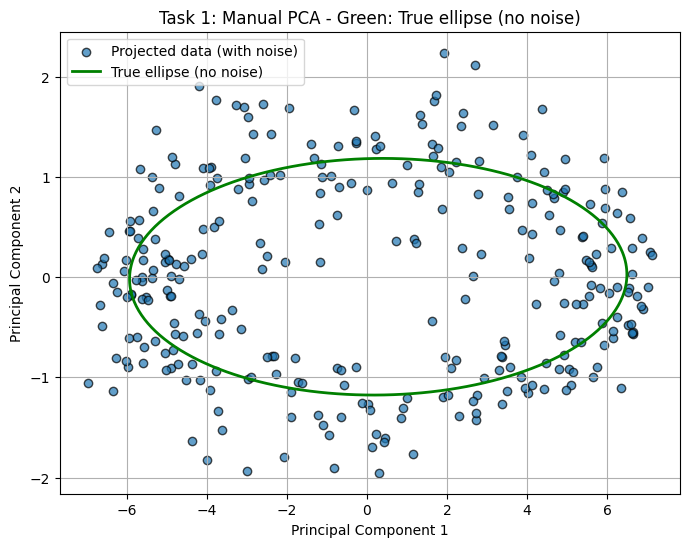

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# データ準備（課題1）
np.random.seed(42)

# 2次元の楕円状データを生成 (サンプル数m=300)
m = 300
theta = np.random.uniform(0, 2 * np.pi, m)
a, b = 2, 1  # 楕円の半径
X_2d = np.column_stack((a * np.cos(theta), b * np.sin(theta)))

# ランダムな回転行列（2x5）を作成し、5次元にリフト + ノイズ付加
W = np.random.randn(2, 5)
X_5d = X_2d @ W + np.random.randn(m, 5) * 0.5

# 1. 中心化して共分散行列を計算 
X_centered = X_5d - np.mean(X_5d, axis=0)
cov_mat = (X_centered.T @ X_centered) / m

# 2. np.linalg.eigh で固有値分解
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

#降順（大きい順）に並べ替える
idx = np.argsort(eigenvalues)[::-1]
eigenvectors_sorted = eigenvectors[:, idx]

# 3. 上位2つの固有ベクトルを取得し、データを射影
top2_eigenvectors = eigenvectors_sorted[:, :2]
X_pca_manual = X_centered @ top2_eigenvectors

# 4. 散布図のプロット
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_manual[:, 0], X_pca_manual[:, 1], alpha=0.7, edgecolor='k', label='Projected data (with noise)')

# 正解の楕円を曲線で描画（パラメトリック形式：(x,y)=(2cos(t), sin(t))）
t_ellipse = np.linspace(0, 2*np.pi, 500)
X_ellipse_2d = np.column_stack((2*np.cos(t_ellipse), np.sin(t_ellipse)))
X_ellipse_lifted = X_ellipse_2d @ W  # ノイズなしで5次元にリフト
X_ellipse_lifted_centered = X_ellipse_lifted - np.mean(X_5d, axis=0)  # 全体の平均で中心化
X_ellipse_pca = X_ellipse_lifted_centered @ top2_eigenvectors  # 同じPCA変換を適用
plt.plot(X_ellipse_pca[:, 0], X_ellipse_pca[:, 1], color='green', linewidth=2, label='True ellipse (no noise)')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Task 1: Manual PCA - Green: True ellipse (no noise)")
plt.grid(True)
plt.legend()
plt.show()

### 課題1の考察

散布図より、ノイズ付きデータが元の図形(x,y) = (2cosθ,sinθ)の周辺に存在しており、ランダムな回転やノイズを加えたデータであっても、PCAによって元の2次元の構造を正しく復元できていることがわかる。最大分散方向を軸として選ぶことで、情報の喪失を抑えつつ次元削減ができることを視覚的に理解できた。

## 課題2: sklearnと比較


MSE（パターン1: そのまま）: 7.687761e-01
MSE（パターン2: sklearn符号反転）: 3.160388e-32
符号反転を修正すると平均二乗誤差(MSE)が十分に小さくなり、両者の結果が一致する。


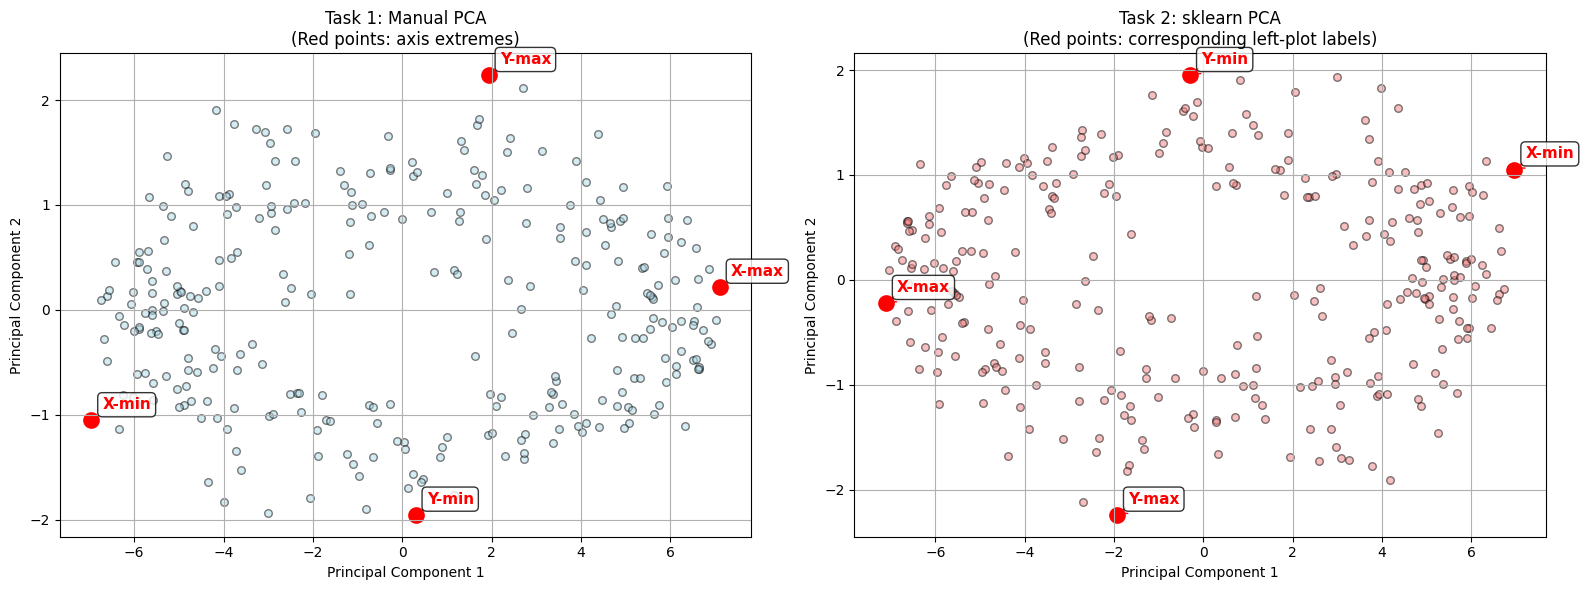

左図中の赤い点は軸の極値点（x軸最大/最小、y軸最大/最小）を強調表示し、対応する点を右図中の赤い点で示している。


In [2]:
from sklearn.decomposition import PCA

# sklearnのPCAを適用（内部で自動的に中心化を行う）
pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_5d)

# 正規化してから比較
def normalize(x):
    return x / np.max(np.abs(x))

X_pca_manual_norm = normalize(X_pca_manual)
X_pca_sklearn_norm = normalize(X_pca_sklearn)

# パターン1の誤差
error1 = np.mean((X_pca_manual_norm - X_pca_sklearn_norm) ** 2)
# パターン2の誤差（符号反転）
error2 = np.mean((X_pca_manual_norm - (-X_pca_sklearn_norm)) ** 2)

print(f"\nMSE（パターン1: そのまま）: {error1:.6e}")
print(f"MSE（パターン2: sklearn符号反転）: {error2:.6e}")
print("符号反転を修正すると平均二乗誤差(MSE)が十分に小さくなり、両者の結果が一致する。")

# 軸の極値点（x軸最大、最小、y軸最大、最小）を強調表示
x_max_idx = np.argmax(X_pca_manual[:, 0])
x_min_idx = np.argmin(X_pca_manual[:, 0])
y_max_idx = np.argmax(X_pca_manual[:, 1])
y_min_idx = np.argmin(X_pca_manual[:, 1])

# ラベルとインデックスのペアを順序付きで保存し、重複インデックスは先に出現したものを使う
label_index_pairs = [
    ('X-max', x_max_idx),
    ('X-min', x_min_idx),
    ('Y-max', y_max_idx),
    ('Y-min', y_min_idx),
]
seen = set()
extreme_points = []
for label, idx in label_index_pairs:
    if idx not in seen:
        extreme_points.append((label, idx))
        seen.add(idx)

# 結果の可視化（軸の極値点を強調）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 課題1の結果
axes[0].scatter(X_pca_manual[:, 0], X_pca_manual[:, 1], alpha=0.5, edgecolor='k', color='lightblue', s=30)
axes[0].scatter([X_pca_manual[idx, 0] for _, idx in extreme_points],
                [X_pca_manual[idx, 1] for _, idx in extreme_points],
                alpha=1.0, edgecolor='red', color='red', s=100, marker='o', linewidth=2)
for label, idx in extreme_points:
    axes[0].annotate(label, (X_pca_manual[idx, 0], X_pca_manual[idx, 1]),
                     xytext=(8, 8), textcoords='offset points', fontsize=11, color='red',
                     fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].set_title("Task 1: Manual PCA\n(Red points: axis extremes)")
axes[0].grid(True)

# sklearn PCAの結果
axes[1].scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], alpha=0.5, edgecolor='k', color='lightcoral', s=30)
axes[1].scatter([X_pca_sklearn[idx, 0] for _, idx in extreme_points],
                [X_pca_sklearn[idx, 1] for _, idx in extreme_points],
                alpha=1.0, edgecolor='red', color='red', s=100, marker='o', linewidth=2)

for label, idx in extreme_points:
    axes[1].annotate(label, (X_pca_sklearn[idx, 0], X_pca_sklearn[idx, 1]),
                     xytext=(8, 8), textcoords='offset points', fontsize=11, color='red',
                     fontweight='bold', arrowprops=dict(arrowstyle='->', color='red'),
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].set_title("Task 2: sklearn PCA\n(Red points: corresponding left-plot labels)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("左図中の赤い点は軸の極値点（x軸最大/最小、y軸最大/最小）を強調表示し、対応する点を右図中の赤い点で示している。")


### 課題2の考察

手動のPCA結果とsklearnによるPCA結果を比較すると、符号反転の修正を行うことでMSEが 約 $0.768$ から $3.16 \times 10^{-32}$ という極めて $0$ に近い値へと劇的に減少した。計算上の符号の任意性を除けば全く同じであることが証明された。

## 課題3: IrisデータのPCA可視化と寄与率

Iris PCA explained variance ratio: [0.92461872 0.05306648]
累積寄与率 (上位2成分): 0.9776852063187963


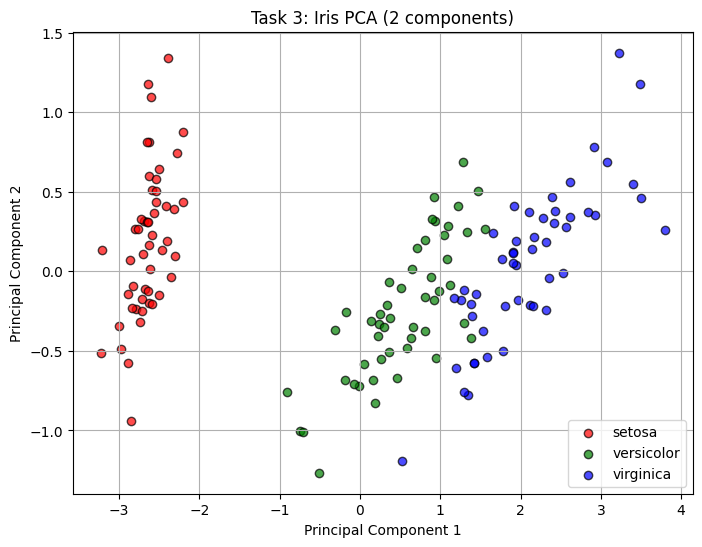

In [3]:
from sklearn.datasets import load_iris

# Irisデータを読み込み
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
labels = iris.target_names

# PCAによる2次元射影
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris)

# 寄与率の表示
explained_ratio = pca_iris.explained_variance_ratio_
print("Iris PCA explained variance ratio:", explained_ratio)
print("累積寄与率 (上位2成分):", explained_ratio.sum())

# クラスごとの散布図
fig, ax = plt.subplots(figsize=(8, 6))
for class_id, color, label in zip(range(3), ["red", "green", "blue"], labels):
    mask = y_iris == class_id
    ax.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], label=label, color=color, alpha=0.7, edgecolor='k')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Task 3: Iris PCA (2 components)")
ax.legend()
ax.grid(True)
plt.show()

### 課題3の考察

出力結果より、上位2成分の累積寄与率が約97.7%に達しており、次元削減が有効に機能しているといえる。散布図においてもクラスごとの明確な分離が確認でき、「データが最もばらつく方向」を主成分として取り出せていると言える。

## 全体の考察

課題1,2より、ライブラリと手実装で主成分の符号反転は起きるが、分散を最大化する射影軸は数学的に完全一致することを確認した。また課題3のIrisデータの分析では、上位2成分で約97.7%の情報を保持したままクラスの分離状況を明瞭に可視化でき、次元削減を行うPCAの有効性を実感した。

## AI利用について

本演習課題の実施にあたり、以下の通りAIを活用した。

* 関数の調査・学習
    * 実現したい処理を行える関数の選定から、必要な引数、内部の処理内容、返り値についてAIに質問し、理解を深めた上で実装と確認を行った。
    * 調査した主な関数・メソッド: `random`, `column_stack`, `linalg.eigh`, `argsort`, `PCA(n_components=2).fit_transform`, `corrcoef`, `load_iris`, `explained_variance_ratio_`

* コードの可読性向上
    * 自身で記述したコードに対し、処理の意図を明確にするための簡潔なコメントアウトをAIに追加させた。

* グラフのプロット（Copilotの活用）
    * グラフの描画に関する実装にはCopilotを活用した。具体的には以下のような指示を与えてコードを生成させた。
        * 「上位2固有ベクトルの射影を散布図にプロットし元の関数 (x,y) = (2cos t, sin t) も重ねて」
        * 「手動PCAとsklearnのPCAを比較する散布図を作成して」
        * 「irisのデータセットの上位2成分の射影の散布図をクラスごとに色分けして」
    * 生成されたコードと出力されたグラフは自分で内容の確認と検証を行った。